In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [56]:
df = pd.read_csv("tren-ligero-cdmx.csv")

In [57]:
df

,fecha,mes,anio,tipo_pago,afluencia
0,2022-01-01,Enero,2022,Prepago,14251.000000
1,2022-01-01,Enero,2022,Gratuidad,1806.000000
2,2022-01-02,Enero,2022,Prepago,21875.000000
3,2022-01-02,Enero,2022,Gratuidad,2259.000000
4,2022-01-03,Enero,2022,Prepago,49290.000000
...,...,...,...,...,...
3219,2026-05-29,Mayo,2026,Gratuidad,17434.878050
3220,2026-05-30,Mayo,2026,Prepago,58193.000000
3221,2026-05-30,Mayo,2026,Gratuidad,8762.461208
3222,2026-05-31,Mayo,2026,Prepago,34591.000000


In [58]:
# ¿Hay datos nulos?
df.isna().sum() # No hay datos nulos

fecha        0
mes          0
anio         0
tipo_pago    0
afluencia    0
dtype: int64

In [59]:
# Dimensiones del Data Frame
print(f"El Data Frame tiene {df.shape[0]} filas")
print(f"El Data Frame tiene {df.shape[1]} columnas")

El Data Frame tiene 3224 filas
El Data Frame tiene 5 columnas


In [60]:
# Exploramos el tipo de dato de cada columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3224 entries, 0 to 3223
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      3224 non-null   str    
 1   mes        3224 non-null   str    
 2   anio       3224 non-null   int64  
 3   tipo_pago  3224 non-null   str    
 4   afluencia  3224 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 126.1 KB


In [61]:
# Cantidad de datos que tiene cada año
df["anio"].value_counts()

anio
2024    732
2022    730
2023    730
2025    730
2026    302
Name: count, dtype: int64

## ⚠️ Observación de la cantidad de datos que tiene cada año

Como se puede observar al ejecutar la celda de
   ```py
   df["anio"].value_counts()
   ```
Todos los años (2022, 2023, 2024...) cuentan con casi la misma cantidad de datos, excepto el año 2026 ya que aún no acaba el año. Lo que nos facilitará el análisis ya que no tendremos datos de más o datos faltantes y teniendo en cuenta que los años del 2022 al 2025 cuentan con casi la misma cantidad de datos podemos hacer una **regresión lineal** para predecir la afluencia del 2026.

## ¿Cuál es la afluencia total por cada año?

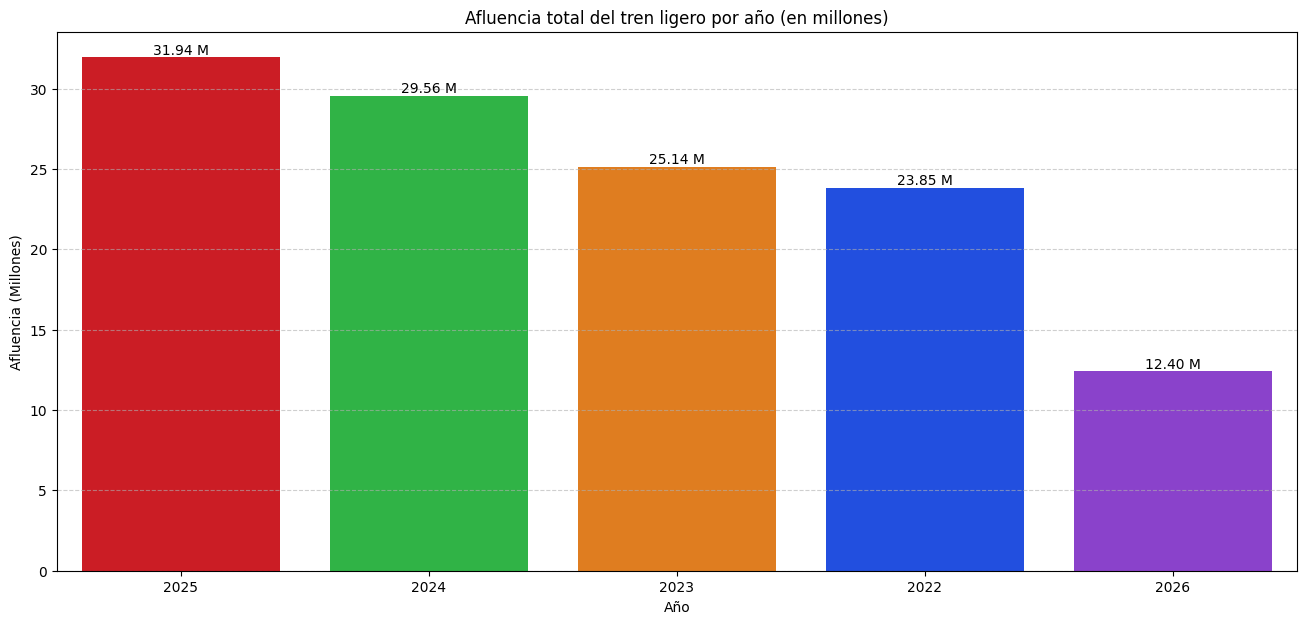

In [69]:
# Agrupamos y ordenamos de mayor a menor
afluencia_por_año = df.groupby("anio")["afluencia"].sum().sort_values(ascending=False)

# Dividimos entre 1,000,000 para simplificar la escala
afluencia_millones = afluencia_por_año / 1_000_000

# 2. Graficamos
plt.figure(figsize=(16, 7))
plt.title("Afluencia total del tren ligero por año (en millones)")

# usamos order=afluencia_millones.index
barras = sns.barplot(x=afluencia_millones.index,
                     y=afluencia_millones.values,
                     hue=afluencia_millones.index,
                     order=afluencia_millones.index,  # <-- Esto frena el reordenamiento automático
                     palette="bright",
                     legend=False)                     # Quita la leyenda repetitiva de los años

for contenedores in barras.containers:
    barras.bar_label(contenedores, fmt='%.2f M')   

plt.ylabel("Afluencia (Millones)")
plt.xlabel("Año")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()

## ¿Qué tanto ha crecido la afluencia del tren ligero cada año?

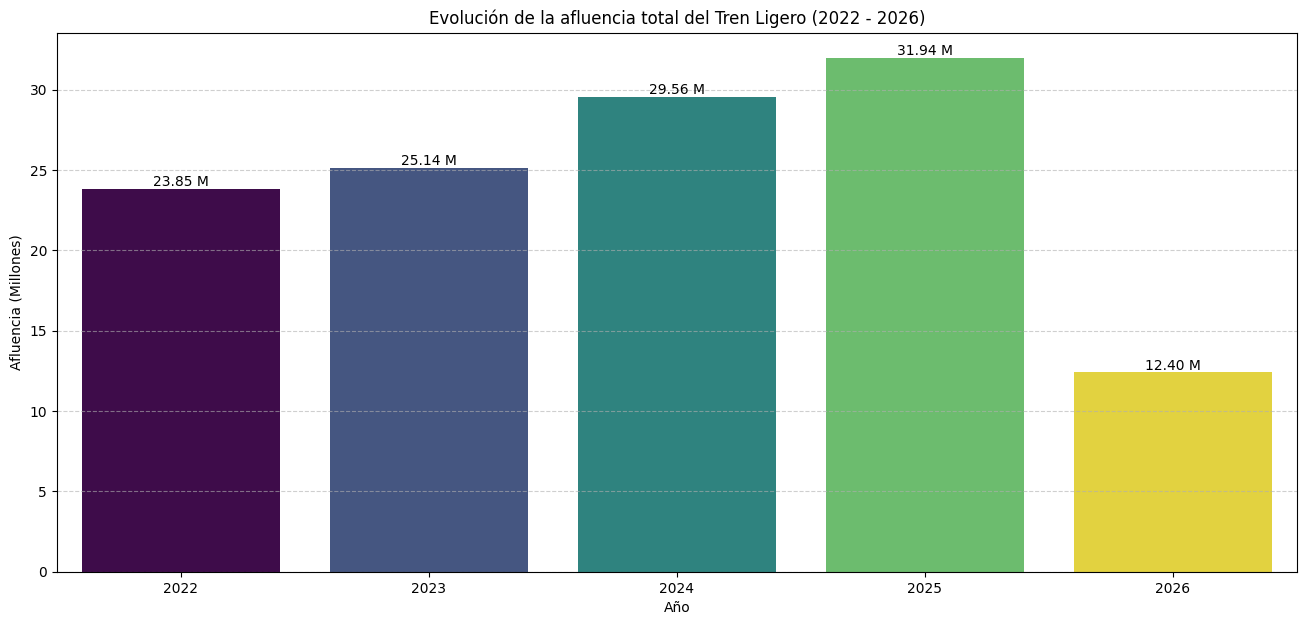

In [84]:
# Agrupamos la afluencia anual pero de manera cronológica
afluencia_cronologica = df.groupby("anio")["afluencia"].sum() / 1_000_000

# Graficamos
plt.figure(figsize=(16,7))
plt.title("Evolución de la afluencia total del Tren Ligero (2022 - 2026)")
barras = sns.barplot(x=afluencia_cronologica.index,
                     y=afluencia_cronologica.values,
                     hue=afluencia_cronologica.index,
                     palette="viridis",
                     legend=False)
for contenedores in barras.containers:
    barras.bar_label(contenedores, fmt='%.2f M')   

plt.ylabel("Afluencia (Millones)")
plt.xlabel("Año")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()